In [1]:
from r1_data_generating import *
import seaborn as sns
from matplotlib.patches import Rectangle




 Loading processed population datasets... 




 Loading MLEs for the processed population datasets... 




In [2]:
# Loading true observations
nt_true = []; n1_true=[]; n2_true=[]; popu_0toT_all = {}
for i in range(0, 9):
    popu_0toT_all[i] = pickle.load(open(file = os.getcwd()+f"/true_popu/popu_dataset{i}.pkl", mode="rb"))
    n_new1 = np.sum(popu_0toT_all[i]["surv"] == 1)
    n_new2 = np.sum(np.isnan(popu_0toT_all[i]["size"])) 

    # growth rate
    nt_true.append((n_new1+n_new2))
    n1_true.append(n_new1)
    n2_true.append(n_new2)

In [ ]:
# Loading simulations
# for MCMCs
a = np.load(open(file = os.getcwd()+"/true_popu/simulations/simu_random.pkl", mode="rb"), allow_pickle=True)
index_random = np.array([sublist for sublist in a[:, 0]])
n1_random = np.array([item for sublist in a[:, 1] for item in sublist])
n2_random = np.array([item for sublist in a[:, 2] for item in sublist])
nt_random = np.array([item for sublist in a[:, 3] for item in sublist])
summary_random = np.array([item for sublist in a[:, 4] for item in sublist])
c_shape = summary_random.shape # reshape
summary_random = summary_random.reshape((c_shape[0], c_shape[1]*c_shape[2]))

a_z = np.load(open(file = os.getcwd()+"/true_popu/simulations/simu_random_z.pkl", mode="rb"), allow_pickle=True)
index_random_z = np.array([sublist for sublist in a_z[:, 0]])
n1_random_z = np.array([item for sublist in a_z[:, 1] for item in sublist])
n2_random_z = np.array([item for sublist in a_z[:, 2] for item in sublist])
nt_random_z = np.array([item for sublist in a_z[:, 3] for item in sublist])
summary_random_z = np.array([item for sublist in a_z[:, 4] for item in sublist])
c_shape = summary_random_z.shape # reshape
summary_random_z = summary_random_z.reshape((c_shape[0], c_shape[1]*c_shape[2]))

# for ABC
b = np.load(open(file = os.getcwd()+"/true_popu/simulations/simu_abc.pkl", mode="rb"), allow_pickle=True)
index_abc = np.array([sublist for sublist in b[:, 0]])
n1_abc = np.array([item for sublist in b[:, 1] for item in sublist])
n2_abc = np.array([item for sublist in b[:, 2] for item in sublist])
nt_abc = np.array([item for sublist in b[:, 3] for item in sublist])
summary_abc = np.array([item for sublist in b[:, 4] for item in sublist])
c_shape = summary_abc.shape # reshape
summary_abc = summary_abc.reshape((c_shape[0], c_shape[1]*c_shape[2]))

b_z = np.load(open(file = os.getcwd()+"/true_popu/simulations/simu_abc_z.pkl", mode="rb"), allow_pickle=True)
index_abc_z = np.array([sublist for sublist in b_z[:, 0]])
n1_abc_z = np.array([item for sublist in b_z[:, 1] for item in sublist])
n2_abc_z = np.array([item for sublist in b_z[:, 2] for item in sublist])
nt_abc_z = np.array([item for sublist in b_z[:, 3] for item in sublist])
summary_abc_z = np.array([item for sublist in b_z[:, 4] for item in sublist])
c_shape = summary_abc_z.shape # reshape
summary_abc_z = summary_abc_z.reshape((c_shape[0], c_shape[1]*c_shape[2]))



# For GLMs
c = np.load(open(file = os.getcwd()+"/true_popu/simulations/glm_simulations", mode="rb"))
n1_glm = np.array(c[:, 0])
n2_glm = np.array(c[:, 1])
nt_glm = np.array(c[:, 2])

c_z = np.load(open(file = os.getcwd()+"/true_popu/simulations/glm_simulations_z", mode="rb"))
n1_glm_z = np.array(c_z[:, 0])
n2_glm_z = np.array(c_z[:, 1])
nt_glm_z = np.array(c_z[:, 2])

In [13]:
nt_random_159 = np.concatenate([np.zeros((5000, 1), dtype='int')+159, nt_random], axis=1)
nt_abc_159 = np.concatenate([np.zeros((5029, 1), dtype='int')+159, nt_abc], axis=1)
nt_glm_159 = np.concatenate([np.zeros((5004, 1), dtype='int')+159, nt_glm], axis=1)
nt_random_z_159 = np.concatenate([np.zeros((5000, 1), dtype='int')+159, nt_random_z], axis=1)
nt_abc_z_159 = np.concatenate([np.zeros((5029, 1), dtype='int')+159, nt_abc_z], axis=1)
nt_glm_z_159 = np.concatenate([np.zeros((5004, 1), dtype='int')+159, nt_glm_z], axis=1)
nt_true_159 = [159]
nt_true_159.extend(nt_true)
iqr_abc = np.around(np.quantile(nt_abc_159, 0.975, axis=0) - np.quantile(nt_abc_159, 0.025, axis=0), 1)
iqr_random = np.around(np.quantile(nt_random_159, 0.975, axis=0) - np.quantile(nt_random_159, 0.025, axis=0), 1)
iqr_glm = np.around(np.quantile(nt_glm_159, 0.975, axis=0) - np.quantile(nt_glm_159, 0.025, axis=0), 1)
iqr_abc_z = np.around(np.quantile(nt_abc_z_159, 0.975, axis=0) - np.quantile(nt_abc_z_159, 0.025, axis=0), 1)
iqr_random_z = np.around(np.quantile(nt_random_z_159, 0.975, axis=0) - np.quantile(nt_random_z_159, 0.025, axis=0), 1)
iqr_glm_z = np.around(np.quantile(nt_glm_z_159, 0.975, axis=0) - np.quantile(nt_glm_z_159, 0.025, axis=0), 1)

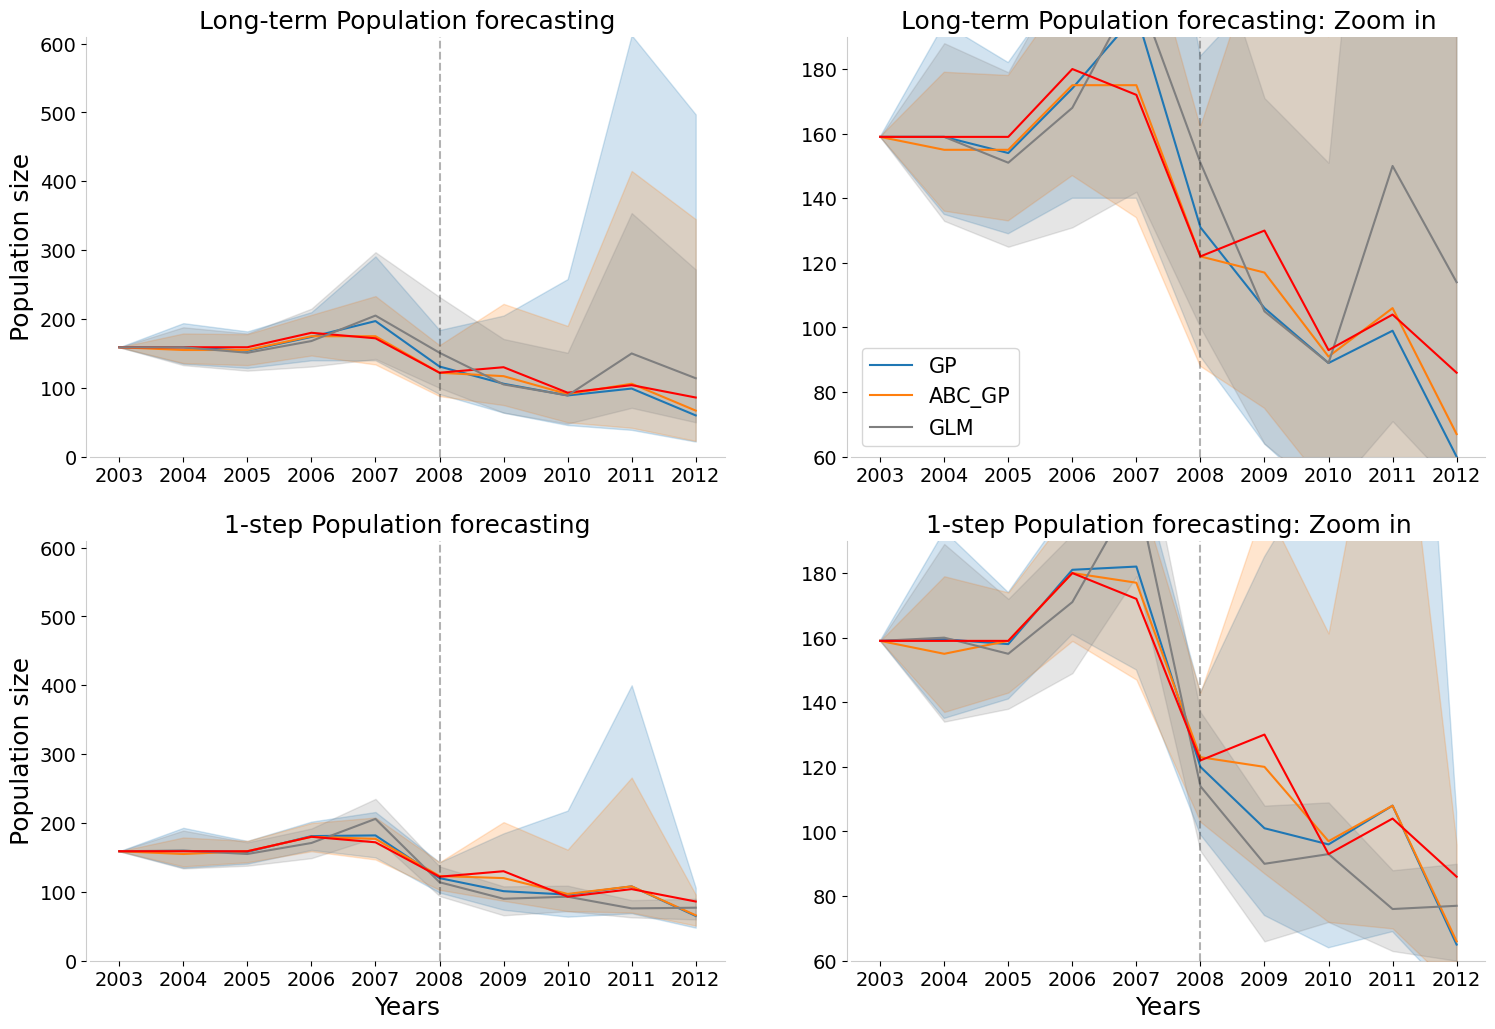

In [ ]:

fig = plt.figure(figsize=(18, 12))
ax = fig.add_subplot(2, 2, 1)
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
ax.spines['left'].set_position(('outward', 3)); ax.spines['left'].set_alpha(0.2); ax.spines['bottom'].set_alpha(0.2)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

plt.plot(np.median(nt_random_159, axis=0), color="C0", label='mcmc_median')
plt.plot(np.median(nt_abc_159, axis=0), color="C1", label='abc_median')
plt.plot(nt_true_159, color="r")
plt.plot(np.median(nt_glm_159, axis=0), color="C7", label='glm_median')


plt.fill_between(
    np.arange(10),
    np.quantile(nt_random_159, 0.025, axis=0), 
    np.quantile(nt_random_159, 0.975, axis=0),
    color="C0",
    alpha=0.2,
)

plt.fill_between(
    np.arange(10),
    np.quantile(nt_abc_159, 0.025, axis=0), 
    np.quantile(nt_abc_159, 0.975, axis=0),
    color="C1",
    alpha=0.2,
)
plt.fill_between(
    np.arange(10),
    np.quantile(nt_glm_159, 0.025, axis=0), 
    np.quantile(nt_glm_159, 0.975, axis=0),
    color="C7",
    alpha=0.2,
)
# for i in range(10): plt.text(i-0.3, 700, iqr_random[i], color='C0', fontsize=14)
# for i in range(10): plt.text(i-0.3, 600, iqr_abc[i], color='C1', fontsize=14)
# for i in range(10): plt.text(i-0.3, 500, iqr_glm[i], color='C7', fontsize=14)
plt.axvline(5, color='k', linestyle='--', alpha=0.3)
plt.xticks(ticks = np.arange(0, 10), labels= np.arange(2003, 2013), fontsize=14)
plt.yticks(fontsize=14)
plt.ylim(0, 610)
plt.ylabel('Population size', fontsize=18)
plt.title('Long-term Population forecasting', fontsize=18)

ax = fig.add_subplot(2, 2, 2)
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
ax.spines['left'].set_position(('outward', 3)); ax.spines['left'].set_alpha(0.2); ax.spines['bottom'].set_alpha(0.2)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.plot(np.median(nt_random_159, axis=0), color="C0", label='GP')
plt.plot(np.median(nt_abc_159, axis=0), color="C1", label='ABC_GP')
plt.plot(np.median(nt_glm_159, axis=0), color="C7", label='GLM')
plt.plot(nt_true_159, color="r")
plt.legend(loc='lower left', fontsize=15)

plt.fill_between(
    np.arange(10),
    np.quantile(nt_random_159, 0.025, axis=0), 
    np.quantile(nt_random_159, 0.975, axis=0),
    color="C0",
    alpha=0.2,
)

plt.fill_between(
    np.arange(10),
    np.quantile(nt_abc_159, 0.025, axis=0), 
    np.quantile(nt_abc_159, 0.975, axis=0),
    color="C1",
    alpha=0.2,
)
plt.fill_between(
    np.arange(10),
    np.quantile(nt_glm_159, 0.025, axis=0), 
    np.quantile(nt_glm_159, 0.975, axis=0),
    color="C7",
    alpha=0.2,
)
plt.ylim(60, 190)
plt.xticks(ticks = np.arange(0, 10), labels= np.arange(2003, 2013), fontsize=14)
plt.yticks(fontsize=14)
# plt.legend()
plt.axvline(5, color='k', linestyle='--', alpha=0.3)
plt.title('Long-term Population forecasting: Zoom in', fontsize=18)



ax = fig.add_subplot(2, 2, 3)
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
ax.spines['left'].set_position(('outward', 3)); ax.spines['left'].set_alpha(0.2); ax.spines['bottom'].set_alpha(0.2)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.plot(np.median(nt_random_z_159, axis=0), color="C0", label='mcmc_median')
plt.plot(np.median(nt_abc_z_159, axis=0), color="C1", label='abc_median')
plt.plot(np.median(nt_glm_z_159, axis=0), color="C7", label='glm_median')
plt.plot(nt_true_159, color="r")

plt.fill_between(
    np.arange(10),
    np.quantile(nt_random_z_159, 0.025, axis=0), 
    np.quantile(nt_random_z_159, 0.975, axis=0),
    color="C0",
    alpha=0.2,
)

plt.fill_between(
    np.arange(10),
    np.quantile(nt_abc_z_159, 0.025, axis=0), 
    np.quantile(nt_abc_z_159, 0.975, axis=0),
    color="C1",
    alpha=0.2,
)

plt.fill_between(
    np.arange(10),
    np.quantile(nt_glm_z_159, 0.025, axis=0), 
    np.quantile(nt_glm_z_159, 0.975, axis=0),
    color="C7",
    alpha=0.2,
)

# for i in range(10): plt.text(i-0.3, 400, iqr_random_z[i], color='C0', fontsize=14)
# for i in range(10): plt.text(i-0.3, 350, iqr_abc_z[i], color='C1', fontsize=14)
# for i in range(10): plt.text(i-0.3, 300, iqr_glm_z[i], color='C7', fontsize=14)

plt.xticks(ticks = np.arange(0, 10), labels= np.arange(2003, 2013), fontsize=14)
plt.yticks(fontsize=14)
plt.axvline(5, color='k', linestyle='--', alpha=0.3)
plt.ylim(0, 610)
plt.ylabel('Population size', fontsize=18)
plt.xlabel('Years', fontsize=18)


plt.title('1-step Population forecasting', fontsize=18)

ax = fig.add_subplot(2, 2, 4)
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
ax.spines['left'].set_position(('outward', 3)); ax.spines['left'].set_alpha(0.2); ax.spines['bottom'].set_alpha(0.2)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.plot(np.median(nt_random_z_159, axis=0), color="C0", label='mcmc_median')
plt.plot(np.median(nt_abc_z_159, axis=0), color="C1", label='abc_median')
plt.plot(np.median(nt_glm_z_159, axis=0), color="C7", label='glm_median')
plt.plot(nt_true_159, color="r")

plt.fill_between(
    np.arange(10),
    np.quantile(nt_random_z_159, 0.025, axis=0), 
    np.quantile(nt_random_z_159, 0.975, axis=0),
    color="C0",
    alpha=0.2,
)

plt.fill_between(
    np.arange(10),
    np.quantile(nt_abc_z_159, 0.025, axis=0), 
    np.quantile(nt_abc_z_159, 0.975, axis=0),
    color="C1",
    alpha=0.2,
)
plt.fill_between(
    np.arange(10),
    np.quantile(nt_glm_z_159, 0.025, axis=0), 
    np.quantile(nt_glm_z_159, 0.975, axis=0),
    color="C7",
    alpha=0.2,
)
plt.ylim(60, 190)

plt.axvline(5, color='k', linestyle='--', alpha=0.3)
plt.title('1-step Population forecasting: Zoom in', fontsize=18)
plt.xticks(ticks = np.arange(0, 10), labels= np.arange(2003, 2013), fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel('Years', fontsize=18)
plt.show()

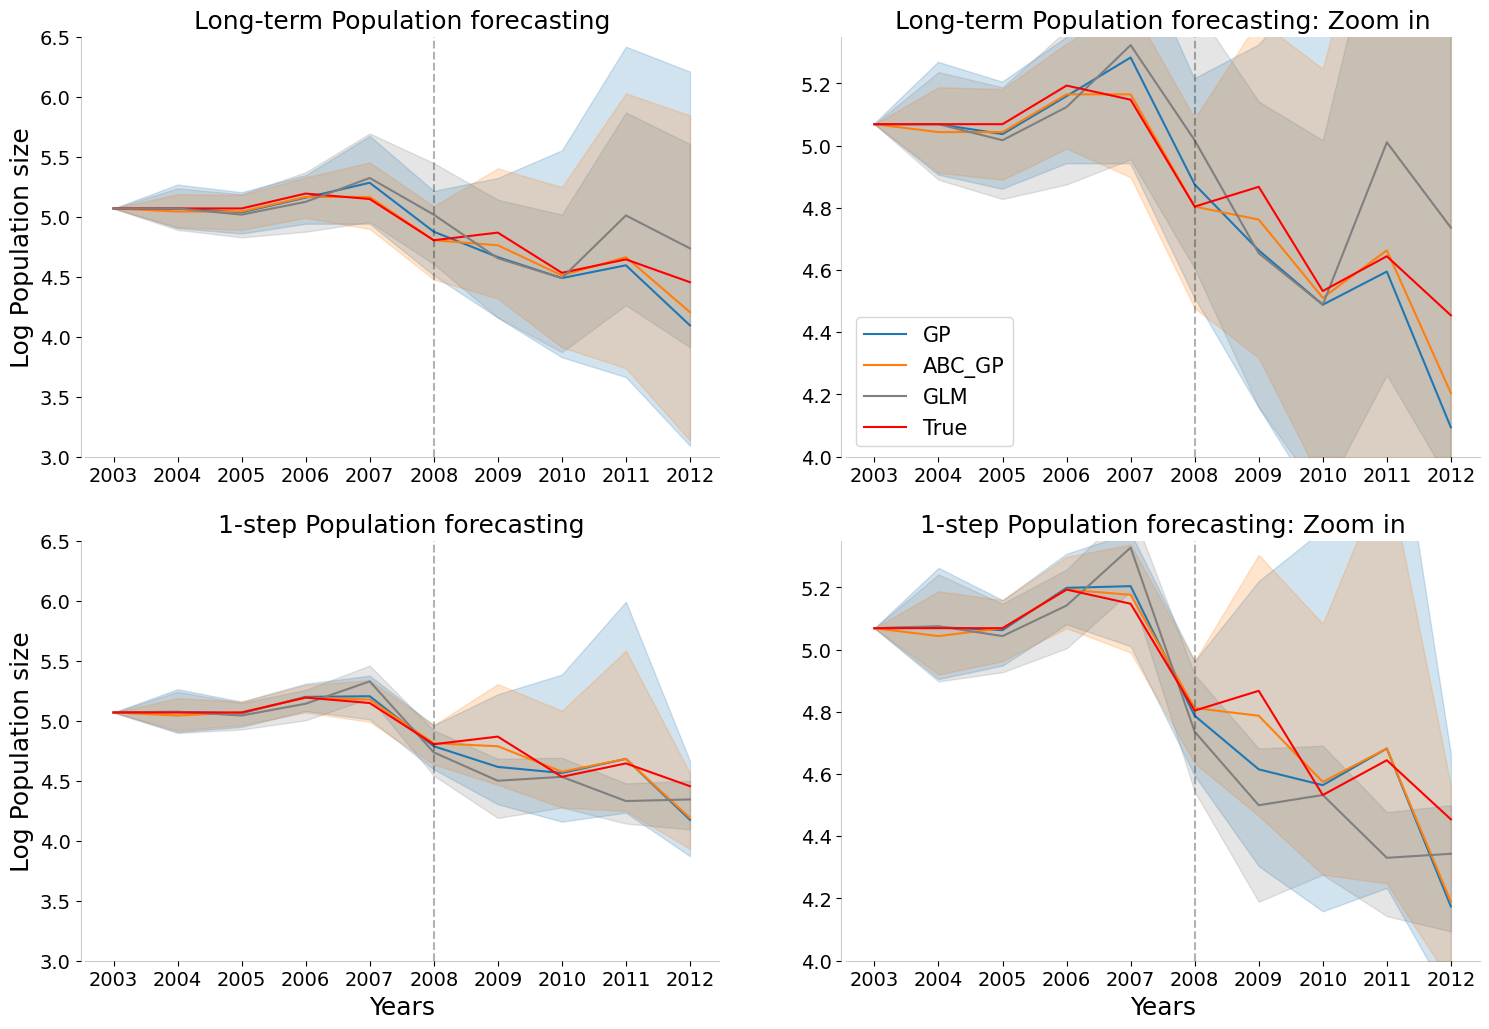

In [ ]:
fig = plt.figure(figsize=(18, 12))
ax = fig.add_subplot(2, 2, 1)
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
ax.spines['left'].set_position(('outward', 3)); ax.spines['left'].set_alpha(0.2); ax.spines['bottom'].set_alpha(0.2)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

plt.plot(np.log(np.median(nt_random_159, axis=0)), color="C0", label='mcmc_median')
plt.plot(np.log(np.median(nt_abc_159, axis=0)), color="C1", label='abc_median')
plt.plot(np.log(nt_true_159), color="r")
plt.plot(np.log(np.median(nt_glm_159, axis=0)), color="C7", label='glm_median')

plt.fill_between(
    np.arange(10),
    np.log(np.quantile(nt_random_159, 0.025, axis=0)), 
    np.log(np.quantile(nt_random_159, 0.975, axis=0)),
    color="C0",
    alpha=0.2,
)

plt.fill_between(
    np.arange(10),
    np.log(np.quantile(nt_abc_159, 0.025, axis=0)), 
    np.log(np.quantile(nt_abc_159, 0.975, axis=0)),
    color="C1",
    alpha=0.2,
)
plt.fill_between(
    np.arange(10),
    np.log(np.quantile(nt_glm_159, 0.025, axis=0)), 
    np.log(np.quantile(nt_glm_159, 0.975, axis=0)),
    color="C7",
    alpha=0.2,
)

plt.axvline(5, color='k', linestyle='--', alpha=0.3)
plt.xticks(ticks = np.arange(0, 10), labels= np.arange(2003, 2013), fontsize=14)
plt.yticks(fontsize=14)
plt.ylabel('Log Population size', fontsize=18)
plt.title('Long-term Population forecasting', fontsize=18)
plt.ylim(3, 6.5)

ax = fig.add_subplot(2, 2, 2)
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
ax.spines['left'].set_position(('outward', 3)); ax.spines['left'].set_alpha(0.2); ax.spines['bottom'].set_alpha(0.2)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.plot(np.log(np.median(nt_random_159, axis=0)), color="C0", label='GP')
plt.plot(np.log(np.median(nt_abc_159, axis=0)), color="C1", label='ABC_GP')
plt.plot(np.log(np.median(nt_glm_159, axis=0)), color="C7", label='GLM')
plt.plot(np.log(nt_true_159), color="r", label='True')
plt.legend(loc='lower left', fontsize=15)

plt.fill_between(
    np.arange(10),
    np.log(np.quantile(nt_random_159, 0.025, axis=0)), 
    np.log(np.quantile(nt_random_159, 0.975, axis=0)),
    color="C0",
    alpha=0.2,
)

plt.fill_between(
    np.arange(10),
    np.log(np.quantile(nt_abc_159, 0.025, axis=0)), 
    np.log(np.quantile(nt_abc_159, 0.975, axis=0)),
    color="C1",
    alpha=0.2,
)
plt.fill_between(
    np.arange(10),
    np.log(np.quantile(nt_glm_159, 0.025, axis=0)), 
    np.log(np.quantile(nt_glm_159, 0.975, axis=0)),
    color="C7",
    alpha=0.2,
)

plt.xticks(ticks = np.arange(0, 10), labels= np.arange(2003, 2013), fontsize=14)
plt.yticks(fontsize=14)
plt.axvline(5, color='k', linestyle='--', alpha=0.3)
plt.title('Long-term Population forecasting: Zoom in', fontsize=18)
plt.ylim(4, 5.35)


ax = fig.add_subplot(2, 2, 3)
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
ax.spines['left'].set_position(('outward', 3)); ax.spines['left'].set_alpha(0.2); ax.spines['bottom'].set_alpha(0.2)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.plot(np.log(np.median(nt_random_z_159, axis=0)), color="C0", label='mcmc_median')
plt.plot(np.log(np.median(nt_abc_z_159, axis=0)), color="C1", label='abc_median')
plt.plot(np.log(np.median(nt_glm_z_159, axis=0)), color="C7", label='glm_median')
plt.plot(np.log(nt_true_159), color="r")

plt.fill_between(
    np.arange(10),
    np.log(np.quantile(nt_random_z_159, 0.025, axis=0)), 
    np.log(np.quantile(nt_random_z_159, 0.975, axis=0)),
    color="C0",
    alpha=0.2,
)

plt.fill_between(
    np.arange(10),
    np.log(np.quantile(nt_abc_z_159, 0.025, axis=0)), 
    np.log(np.quantile(nt_abc_z_159, 0.975, axis=0)),
    color="C1",
    alpha=0.2,
)

plt.fill_between(
    np.arange(10),
    np.log(np.quantile(nt_glm_z_159, 0.025, axis=0)), 
    np.log(np.quantile(nt_glm_z_159, 0.975, axis=0)),
    color="C7",
    alpha=0.2,
)


plt.xticks(ticks = np.arange(0, 10), labels= np.arange(2003, 2013), fontsize=14)
plt.yticks(fontsize=14)
plt.axvline(5, color='k', linestyle='--', alpha=0.3)
plt.ylabel('Log Population size', fontsize=18)
plt.xlabel('Years', fontsize=18)
plt.ylim(3, 6.5)

plt.title('1-step Population forecasting', fontsize=18)

ax = fig.add_subplot(2, 2, 4)
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
ax.spines['left'].set_position(('outward', 3)); ax.spines['left'].set_alpha(0.2); ax.spines['bottom'].set_alpha(0.2)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.plot(np.log(np.median(nt_random_z_159, axis=0)), color="C0", label='mcmc_median')
plt.plot(np.log(np.median(nt_abc_z_159, axis=0)), color="C1", label='abc_median')
plt.plot(np.log(np.median(nt_glm_z_159, axis=0)), color="C7", label='glm_median')
plt.plot(np.log(nt_true_159), color="r")

plt.fill_between(
    np.arange(10),
    np.log(np.quantile(nt_random_z_159, 0.025, axis=0)), 
    np.log(np.quantile(nt_random_z_159, 0.975, axis=0)),
    color="C0",
    alpha=0.2,
)

plt.fill_between(
    np.arange(10),
    np.log(np.quantile(nt_abc_z_159, 0.025, axis=0)), 
    np.log(np.quantile(nt_abc_z_159, 0.975, axis=0)),
    color="C1",
    alpha=0.2,
)
plt.fill_between(
    np.arange(10),
    np.log(np.quantile(nt_glm_z_159, 0.025, axis=0)), 
    np.log(np.quantile(nt_glm_z_159, 0.975, axis=0)),
    color="C7",
    alpha=0.2,
)

plt.axvline(5, color='k', linestyle='--', alpha=0.3)
plt.title('1-step Population forecasting: Zoom in', fontsize=18)
plt.xticks(ticks = np.arange(0, 10), labels= np.arange(2003, 2013), fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel('Years', fontsize=18)
plt.ylim(4, 5.35)
# plt.savefig('plot_1.pdf')  
plt.show()

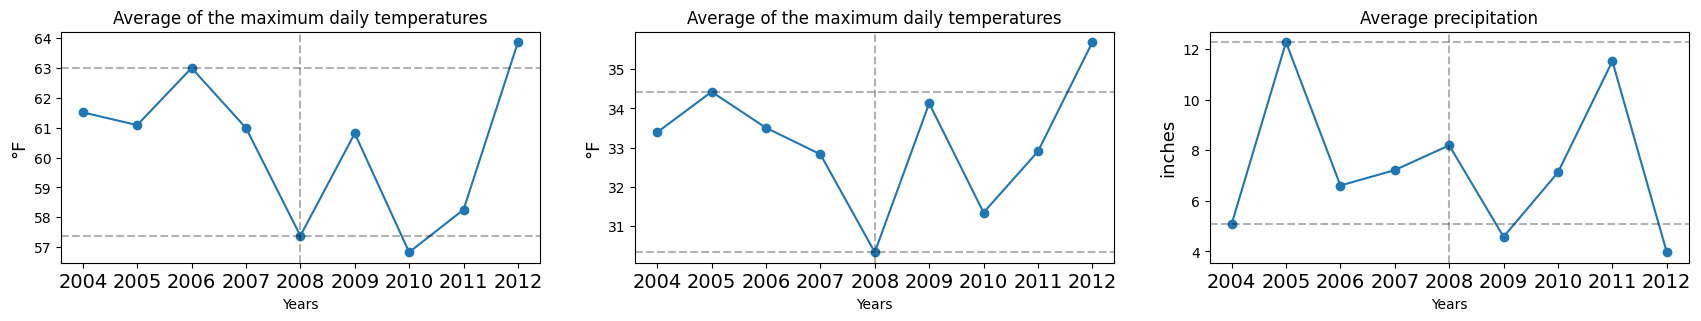

In [ ]:
fig = plt.figure(figsize=(21, 3))
for i in range(3):
    ax = fig.add_subplot(1, 3, i+1)
    plt.plot(range(9), w.iloc[i,:], '-o')
    plt.axvline(4, color='k', linestyle='--', alpha=0.3)
    plt.axhline(min(w.iloc[i,:5]), color='k', linestyle='--', alpha=0.3)
    plt.axhline(max(w.iloc[i,:5]), color='k', linestyle='--', alpha=0.3)
    plt.title(['Average of the maximum daily temperatures', 'Average of the maximum daily temperatures', 'Average precipitation'][i])
    plt.ylabel(['°F', '°F', 'inches'][i], fontsize=13)
    plt.xlabel('Years')
    plt.xticks(ticks = np.arange(0, 9), labels= np.arange(2004, 2013), fontsize=14)

plt.show()

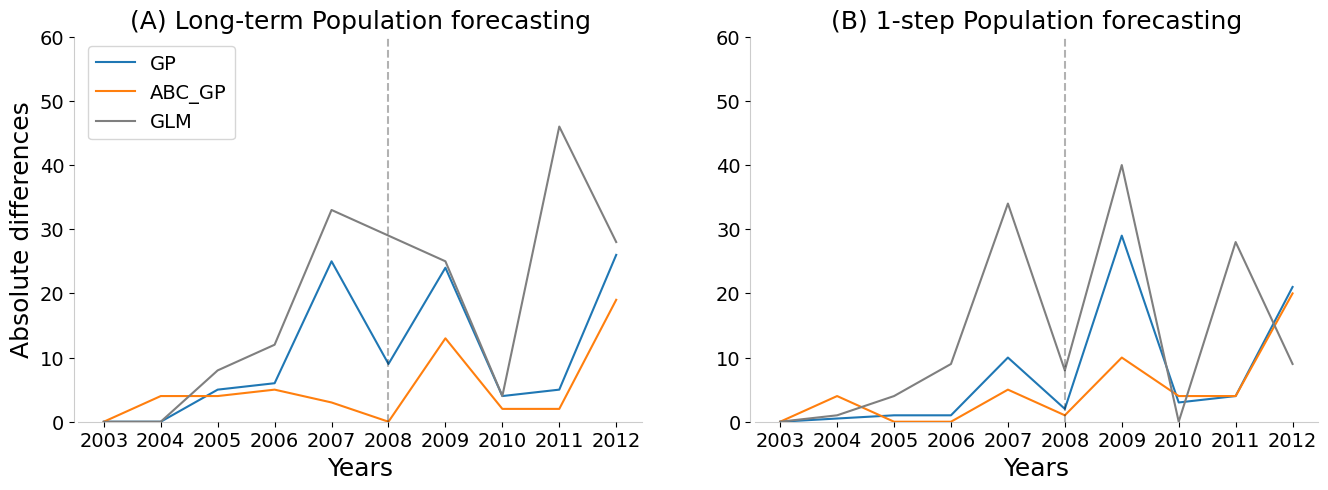

In [ ]:
fig = plt.figure(figsize=(16, 5))
# fig.suptitle('Absolute differences in population size', fontsize=18)
ax = fig.add_subplot(1, 2, 1)
ax.spines['left'].set_position(('outward', 3)); ax.spines['left'].set_alpha(0.2); ax.spines['bottom'].set_alpha(0.2)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.title('(A) Long-term Population forecasting', fontsize=18)
plt.plot(np.abs(np.median(nt_random_159, axis=0)-nt_true_159), color="C0", label='GP')

plt.plot(np.abs(np.median(nt_abc_159, axis=0)-nt_true_159), color="C1", label='ABC_GP')

plt.plot(np.abs(np.median(nt_glm_159, axis=0)-nt_true_159), color="C7", label='GLM')

plt.legend(fontsize=14, loc='upper left')
plt.axvline(5, color='k', linestyle='--', alpha=0.3)
plt.ylim((0, 60))
plt.ylabel('Absolute differences', fontsize=18)
plt.xlabel('Years', fontsize=18)
plt.xticks(ticks = np.arange(0, 10), labels= np.arange(2003, 2013), fontsize=14)
plt.yticks(fontsize=14)


ax = fig.add_subplot(1, 2, 2)
ax.spines['left'].set_position(('outward', 3)); ax.spines['left'].set_alpha(0.2); ax.spines['bottom'].set_alpha(0.2)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.title('(B) 1-step Population forecasting', fontsize=18)
plt.plot(np.abs(np.median(nt_random_z_159, axis=0)-nt_true_159), color="C0", label='mcmc_median')

plt.plot(np.abs(np.median(nt_abc_z_159, axis=0)-nt_true_159), color="C1", label='abc_median')

plt.plot(np.abs(np.median(nt_glm_z_159, axis=0)-nt_true_159), color="C7", label='glm_median')
# plt.legend()
plt.axvline(5, color='k', linestyle='--', alpha=0.3)
plt.ylim((0, 60))
plt.xticks(ticks = np.arange(0, 10), labels= np.arange(2003, 2013), fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel('Years', fontsize=18)

plt.show()

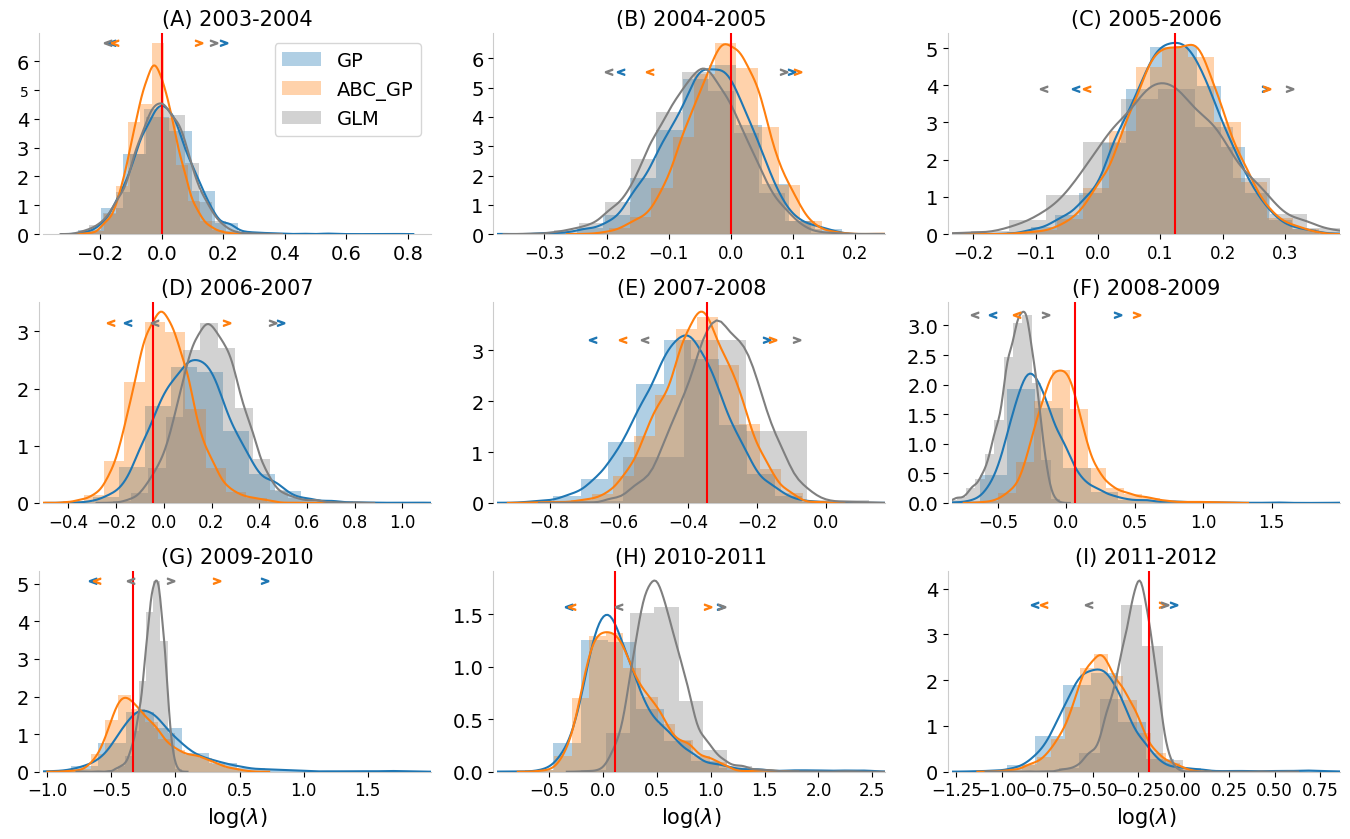

In [39]:
# Log scaled
lambda_mcmc = np.log(nt_random[:, 1:9] / nt_random[:, 0:8])
lambda_abc = np.log(nt_abc[:, 1:9] / nt_abc[:, 0:8])
# np.where(nt_glm[:, 1:9] == 0)
nt_glmfixed = np.copy(nt_glm)
nt_glmfixed = np.delete(nt_glmfixed, [386, 3636, 4796], axis=0)
lambda_glm = np.log(nt_glmfixed[:, 1:9] / nt_glmfixed[:, 0:8])
lambda_true = np.log(np.array(nt_true)[1:] / np.array(nt_true)[:-1])

fig = plt.figure(figsize=(13.6, 8.5))
# fig.suptitle('Simulated single-year population growth rates (long-term forecasting)', fontsize=19)
ax = fig.add_subplot(3, 3, 1)
ax.spines['left'].set_position(('outward', 3)); ax.spines['left'].set_alpha(0.2); ax.spines['bottom'].set_alpha(0.2)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.hist(np.log(nt_random[:, 0] / 159), alpha= 0.35, density=True, bins=14, label='GP')
sns.kdeplot(np.log(nt_random[:, 0] / 159), color='C0')
height = plt.hist(np.log(nt_abc[:, 0] / 159), alpha= 0.35, density=True, bins=14, label='ABC_GP')
sns.kdeplot(np.log(nt_abc[:, 0] / 159), color='C1')
plt.axvline(np.log(nt_true[0] / 159), color='red')
plt.hist(np.log(nt_glm[:, 0] / 159), alpha= 0.35, density=True, bins=14, label='GLM', color='C7')
sns.kdeplot(np.log(nt_glm[:, 0] / 159), color='C7')

# plt.ylabel("Density", fontsize=15) 
plt.plot(np.quantile(np.log(nt_random[:, 0] / 159), 0.975), np.max(height[0]), marker='$>$', color='C0') 
plt.plot(np.quantile(np.log(nt_random[:, 0] / 159), 0.025), np.max(height[0]), marker='$<$', color='C0')
plt.plot(np.quantile(np.log(nt_abc[:, 0] / 159), 0.975), np.max(height[0]), marker='$>$', color='C1')
plt.plot(np.quantile(np.log(nt_abc[:, 0] / 159), 0.025), np.max(height[0]), marker='$<$', color='C1')
plt.plot(np.quantile(np.log(nt_glm[:, 0] / 159), 0.975), np.max(height[0]), marker='$>$', color='C7')
plt.plot(np.quantile(np.log(nt_glm[:, 0] / 159), 0.025), np.max(height[0]), marker='$<$', color='C7')
plt.ylabel(" ", fontsize=1) 

plt.legend(fontsize=14)
plt.yticks(fontsize=14)
plt.xticks(fontsize=14)
plt.title('(A) 2003-2004', fontsize=15)
for i in range(0, 8):
    ax = fig.add_subplot(3, 3, i+2)
    ax.spines['left'].set_position(('outward', 3)); ax.spines['left'].set_alpha(0.2); ax.spines['bottom'].set_alpha(0.2)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    if 4+i < 9:
        title = f'200{4+i}-200{5+i}'
    elif 4+i == 9:
        title = f'2009-2010'
    else:
        title = f'20{4+i}-20{5+i}'
    label = f"({chr(66 + i)})"

    ax.set_title(f"{label} {title}", fontsize=15)
    plt.yticks(fontsize=14)
    plt.xticks(fontsize=12)
    plt.hist(lambda_mcmc[:, i], alpha=0.35, density=True, bins=14)
    plt.hist(lambda_abc[:, i], alpha=0.35, density=True, bins=14)
    height = plt.hist(lambda_glm[:, i], alpha=0.35, density=True, bins=14, color='C7')
    plt.xlim((np.min(np.append(lambda_mcmc[:, i], lambda_abc[:, i])), 
              np.max(np.append(lambda_mcmc[:, i], lambda_abc[:, i]))))

    sns.kdeplot(lambda_mcmc[:, i], color='C0')
    sns.kdeplot(lambda_abc[:, i], color='C1')    
    sns.kdeplot(lambda_glm[:, i], color='C7')    
    plt.axvline(lambda_true[i], color='red')

    plt.plot(np.quantile(lambda_mcmc[:, i], 0.975), np.max(height[0]), color='C0', marker='$>$')
    plt.plot(np.quantile(lambda_mcmc[:, i], 0.025), np.max(height[0]), color='C0', marker='$<$')
    plt.plot(np.quantile(lambda_abc[:, i], 0.975), np.max(height[0]), color='C1', marker='$>$')
    plt.plot(np.quantile(lambda_abc[:, i], 0.025), np.max(height[0]), color='C1', marker='$<$')
    plt.plot(np.quantile(lambda_glm[:, i], 0.975), np.max(height[0]), color='C7', marker='$>$')
    plt.plot(np.quantile(lambda_glm[:, i], 0.025), np.max(height[0]), color='C7', marker='$<$')
    plt.ylabel(" ", fontsize=1) 
    # if (i == 2) or (i == 5): plt.ylabel("Density", fontsize=15) 
    if i > 4: plt.xlabel(r"$\log(\lambda)$", fontsize=15)

plt.tight_layout()

# fig.savefig('plot4.pdf')  

plt.show()



In [6]:
sample_abc = pd.read_csv(os.getcwd()+"/true_popu/simulations/sample_para_abc.csv"); sample_abc = sample_abc.drop(columns=sample_abc.columns[0])
sample_random = pd.read_csv(os.getcwd()+"/true_popu/simulations/sample_para_random.csv"); sample_random = sample_random.drop(columns=sample_random.columns[0])
vital_groups = np.array(['sur', 'sur', 'sur', 'sur', 'sur', 'sur', 
                         'grw_f', 'grw_f', 'grw_f', 'grw_f', 'grw_f', 'grw_f', 'grw_f', 
                         'grw_nf', 'grw_nf', 'grw_nf', 'grw_nf', 'grw_nf', 'grw_nf', 'grw_nf', 
                         'fec', 'fec', 'fec', 'fec', 'fec', 'fec', 
                         'flow', 'flow', 'flow', 'flow', 'flow', 'flow'])

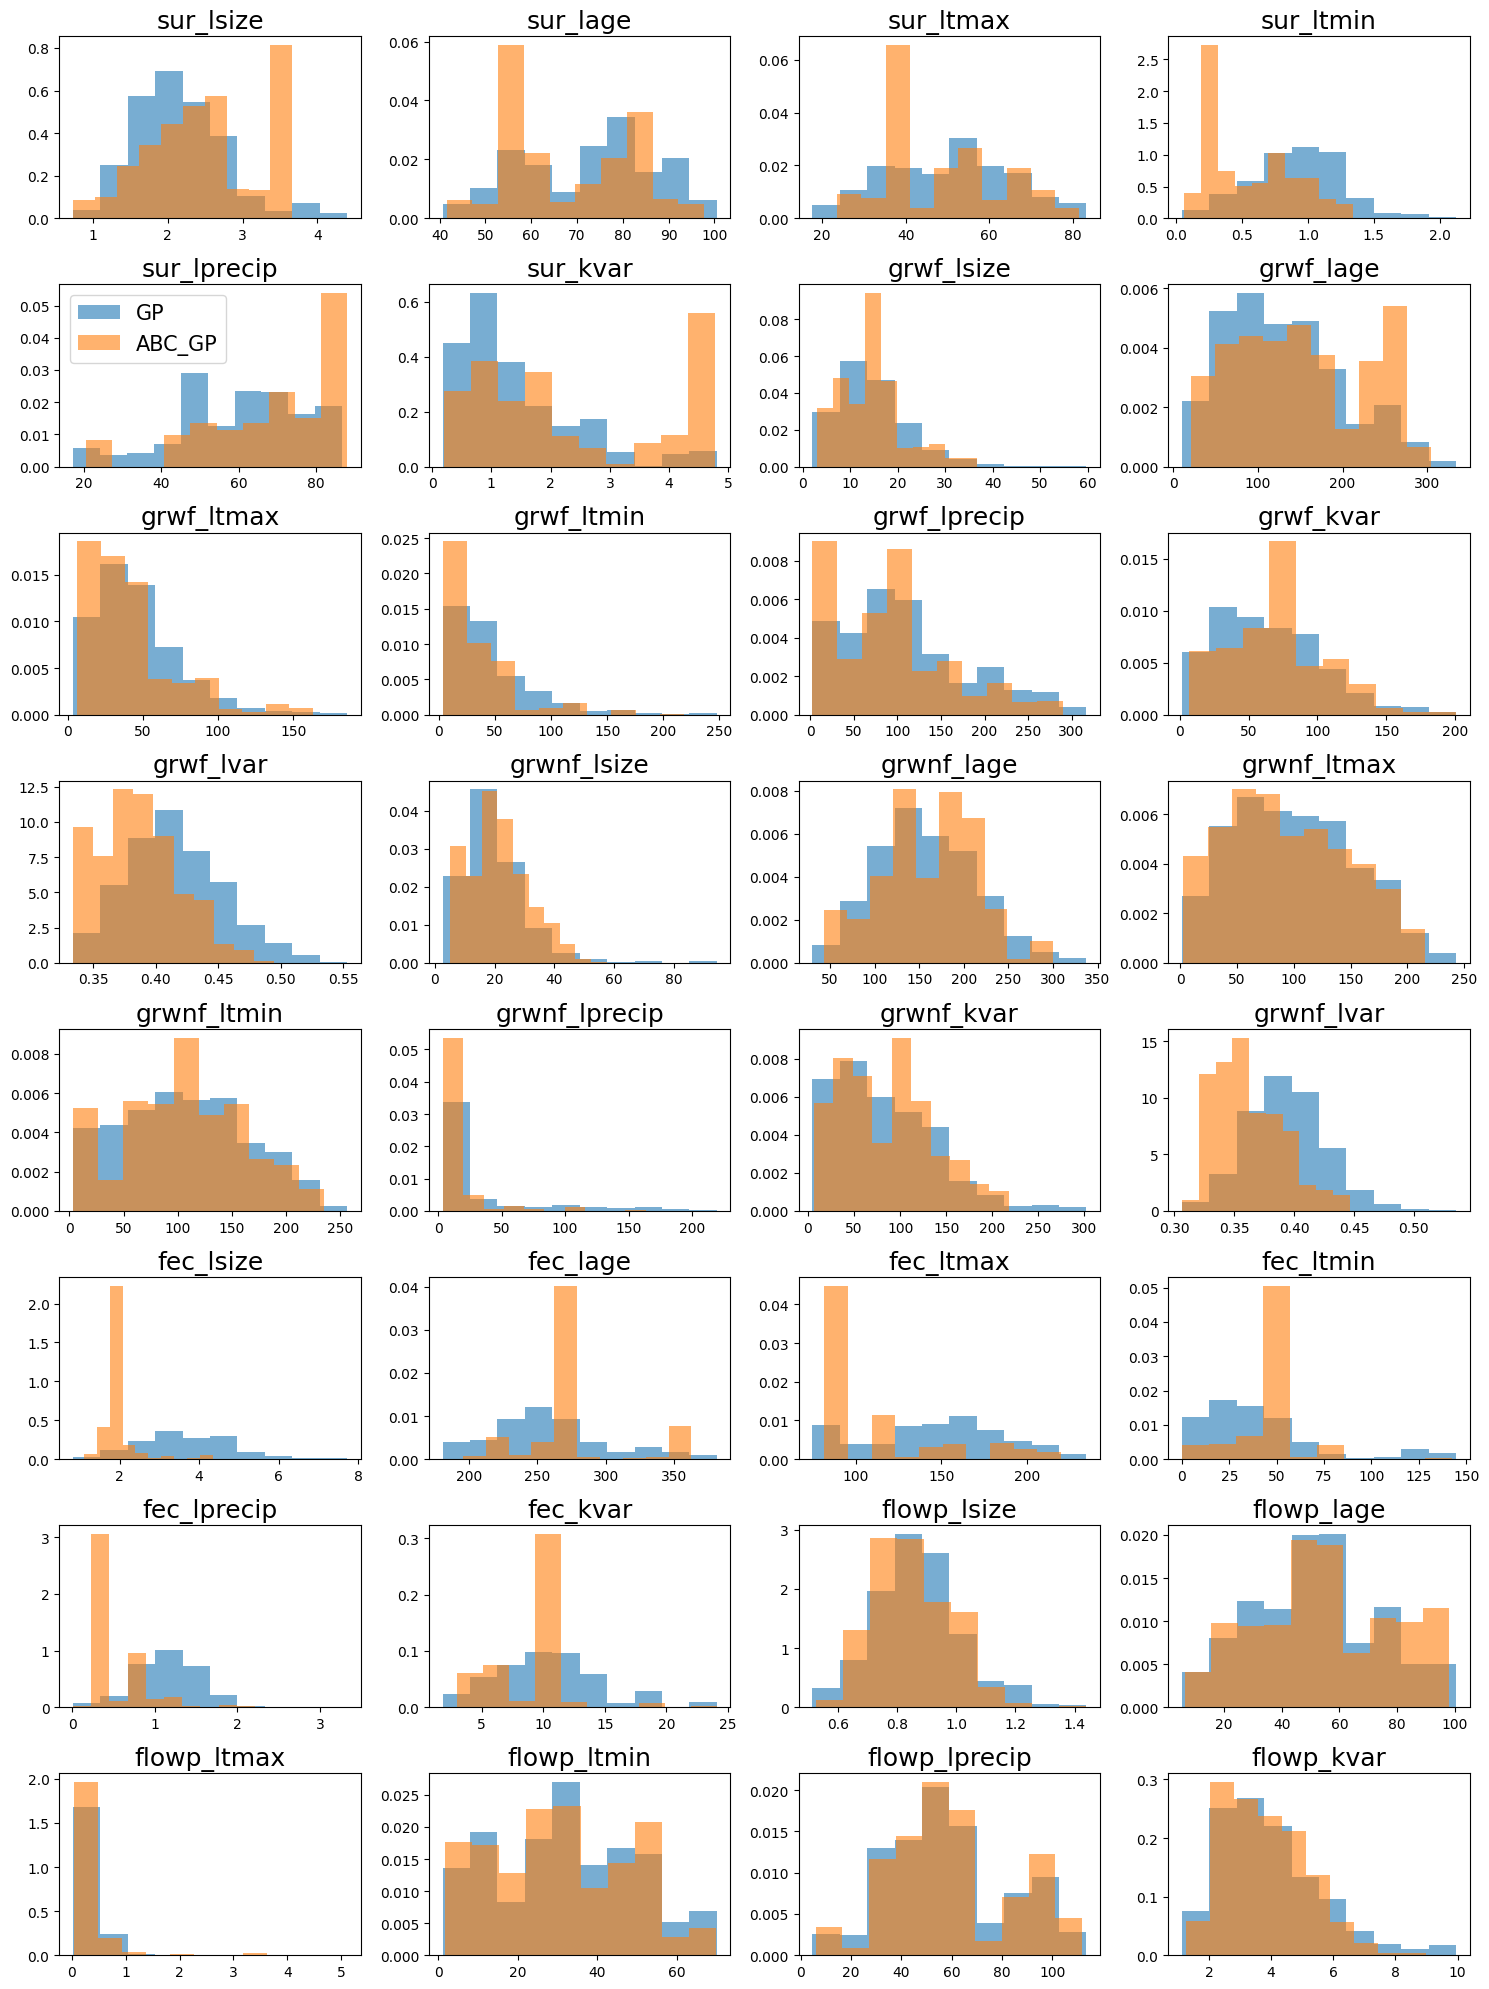

In [10]:
fig = plt.figure(figsize=(15, 20))
for j in range(32):
    ax = fig.add_subplot(8, 4, j+1)
    #plt.xlim((np.min(sample_random.iloc[:, j]), np.max(sample_random.iloc[:, j])))
    plt.hist(sample_random.iloc[:, j], density=True, label='GP', alpha=0.6)
    plt.hist(sample_abc.iloc[:, j], density=True, label='ABC_GP', alpha=0.6)
    plt.title(sample_random.iloc[:, j].name, fontsize=18)
    if j == 4: plt.legend(fontsize=15)
plt.tight_layout()
# plt.savefig('plot12.pdf')  

plt.show()